# O2 dissociation example

Adapted from https://github.com/mutationpp/Mutationpp/blob/master/examples/c%2B%2B/O2_dissociation/O2_dissociation.cpp.

In this notebook, we will use M++ python package to compute an adiabatic reactor for an air mixture composed by two species such that,
$$
\mathcal{S} = [O, O_2].
$$

For this case, the species continuity equation reduces to an ODE and the mixture energy and volume are constant,

$$
\partial_t \rho_i = \dot{\omega_i} \quad \forall i \in \mathcal{S}, \\
\rho e(\rho_i, T) = \text{const}.
$$

The ODE is integrated by a first order Euler explicit method. 

This example program simulates a constant volume, adiabatic reactor beginning with pure $O_2$ at $4000$ K and density of $2.85 10^{-4}$ kg/m^3

*Run the following cell to initialize the necessary packages*

In [1]:
# Import desired packages
import mutationpp as mpp
import numpy as np
import matplotlib.pyplot as plt
from labellines import labelLines
from cycler import cycler

In this cell, we define some parameters for beautiful plotting.

In [2]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
cc = cycler('linestyle', ['-', '--', ':', '-.', '-']) * cycler('color', ['r', 'g', 'b', 'm', 'k'])
plt.rc('axes', prop_cycle=cc)

plt.rc('text', usetex=True)
plt.rc('font', family='Helvetica')

## Initiallizing the mixture from mutation++

The magic starts in the following cells. 

Before initializing the mixture, we need to set-up the desired options for our adiabatic conditions.
The first step is to specify the mixture name, which is the **air_11** mixture, and the thermal database we want to use (**NASA-9**).
Afterward, we specify the state model to be used on our reactor. In this case, we are interested in a one-temperature chemical non-equilibrium model. 
Other models can be used, such as **ChemNonEqTTv** for a two-temperature model and **EquilTP** for a thermo-chemical equilibrium model.

We can print the species within our mixture by using the **getSpeciesDescriptor()** method.

In [3]:
# opts = mpp.MixtureOptions()
# opts.setSpeciesDescriptor("O O2")
# opts.setThermodynamicDatabase("RRHO")
# opts.setMechanism("O2")
# opts.setStateModel("ChemNonEq1T")

opts = mpp.MixtureOptions("O2")
mix = mpp.Mixture(opts)
ns = mix.nSpecies()

print("Mixture species:", opts.getSpeciesDescriptor())

Mixture species: O O2


After, we initialize our mixture based on the options chosen above.

Note, that one could initilize the mixture directly using the mixture name such that,

```python
     mix = mpp.Mixture("O2")
```

The options above would need to be specified directly in the mixture file **O2.xml**.

Later, we set the state using the intial composition and temperature $\rho = 2.85 10^{-4} kg/m^3$.


*Note that one could set state using different options such that:*
  * Sets the current state of the mixture.  Variable sets can be the following:
     *   0: conserved variables (species densities, total energy density)
     *   1: primitive set 1 (species densities, mixture temperature)

In [4]:
T_init   = 4000.0
rho_init = 2.85e-4

rhoi = [0, rho_init]
mix.setState(rhoi,T_init,1)
etot = mix.mixtureEnergyMass()*mix.density()

We now define the initial and finaly conditions:

In [5]:
time = 0.0
time_final = 1
tout = 1.0e-3  # start with a small print interval, just like in your C++
dt = 0

y0 = np.divide(rhoi,mix.density())
x0 = mix.convert_y_to_x(y0)

print("Mixture species:", opts.getSpeciesDescriptor())
print("Mass fractions :", y0)
print("T, P, rho, Etot :", mix.T(), mix.P(), mix.density(),mix.mixtureEnergyMass())

temperature = np.array(mix.T())
pressure = np.array(mix.P())
density = np.array(mix.density())
mass_fractions = np.array([y0])
mole_fractions =  np.array([x0])
time_reaction = np.array(time)
Cps = np.array(mix.mixtureFrozenCpMass())

Mixture species: O O2
Mass fractions : [0. 1.]
T, P, rho, Etot : 4000.0 296.21415410027544 0.00028500000000000004 3304586.6614317135


## ODE integration 

After everything is set, we can start integrating our ODE.

In [6]:
while (time < time_final):
   wdot = mix.netProductionRates()

   for i in range(mix.nSpecies()):
      dt += 1.0e-3 * abs(rho_init * mix.Y()[i] / wdot[i])
   dt = min(dt / mix.nSpecies(), tout - time)

   rhoi += wdot*dt
   time += dt

   mix.setState(rhoi, etot, 0)

   y = mix.Y()
   x = mix.convert_y_to_x(np.array(y))

   mass_fractions = np.vstack((mass_fractions,[y]))
   mole_fractions =  np.vstack((mole_fractions,[x]))
   temperature = np.vstack((temperature,mix.T()))
   pressure = np.vstack((pressure,mix.P()))
   density = np.vstack((density,mix.density()))
   time_reaction  = np.vstack((time_reaction,time))
   Cps = np.vstack((Cps,mix.mixtureFrozenCpMass()))

   if abs(tout - time) < 1.0e-10:
      print(f"time = {time:.6e} s")
      print(f"T = {mix.T():.3f} K")
      print(f"Y = {mix.Y()}")

      # Increment output interval in steps (like C++)
      if tout > 9.9:
         tout += 10.0
      elif tout > 0.99:
         tout += 1.0
      elif tout > 0.099:
         tout += 0.1
      elif tout > 0.0099:
         tout += 0.01
      elif tout > 0.00099:
         tout += 0.001
      else:
         tout += 0.0001


time = 1.000000e-03 s
T = 3784.384 K
Y = [0.01483262 0.98516738]
time = 2.000000e-03 s
T = 3662.958 K
Y = [0.02307708 0.97692292]
time = 3.000000e-03 s
T = 3580.388 K
Y = [0.02863819 0.97136181]
time = 4.000000e-03 s
T = 3518.510 K
Y = [0.03278159 0.96721841]
time = 5.000000e-03 s
T = 3469.443 K
Y = [0.03605242 0.96394758]
time = 6.000000e-03 s
T = 3428.990 K
Y = [0.03873924 0.96126076]
time = 7.000000e-03 s
T = 3394.855 K
Y = [0.04099946 0.95900054]
time = 8.000000e-03 s
T = 3365.384 K
Y = [0.04294575 0.95705425]
time = 9.000000e-03 s
T = 3339.322 K
Y = [0.04466299 0.95533701]
time = 1.000000e-02 s
T = 3316.321 K
Y = [0.04617547 0.95382453]
time = 2.000000e-02 s
T = 3167.557 K
Y = [0.05588759 0.94411241]
time = 3.000000e-02 s
T = 3085.222 K
Y = [0.06121059 0.93878941]
time = 4.000000e-02 s
T = 3029.202 K
Y = [0.06481094 0.93518906]
time = 5.000000e-02 s
T = 2987.410 K
Y = [0.06748561 0.93251439]
time = 6.000000e-02 s
T = 2954.055 K
Y = [0.06961344 0.93038656]
time = 7.000000e-02 s
T =

## Plotting the solution

Finally, we can plot the evolution of the species mole fraction and the temperature relaxation in time

[Text(0.3644479526572236, 0.16146850232114784, 'O'),
 Text(0.723456383632996, 0.8292528998815233, 'O2')]

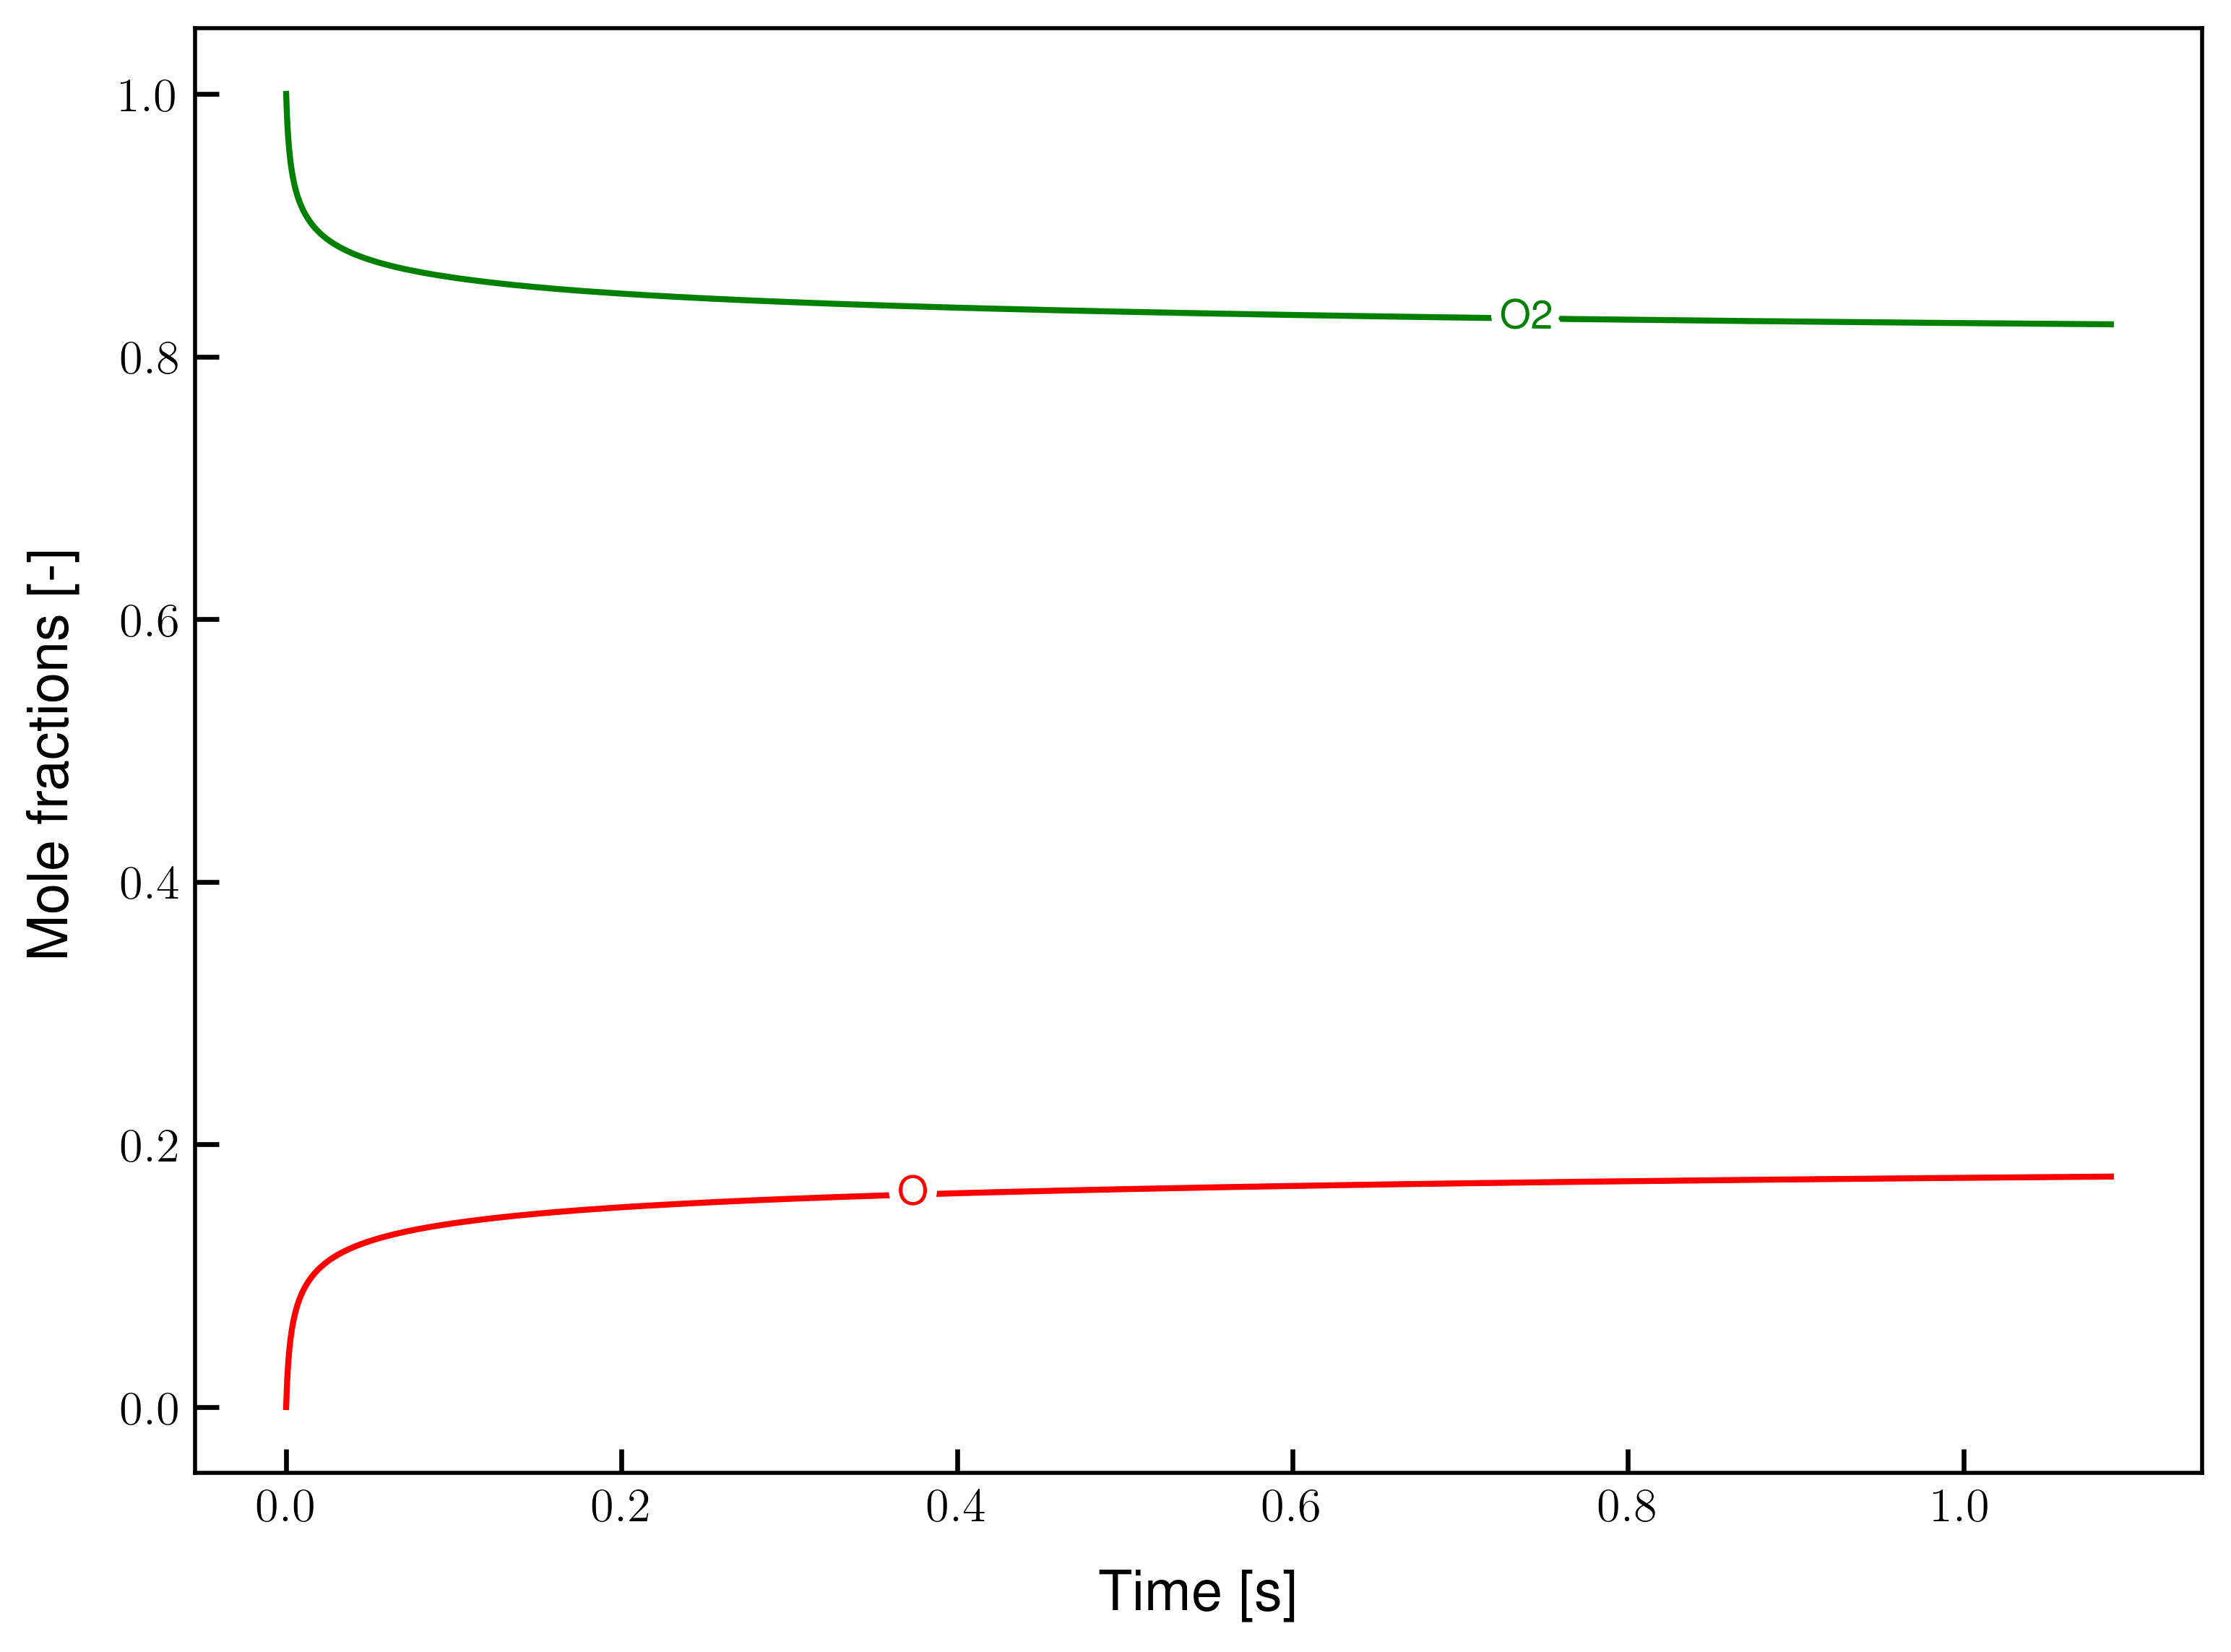

In [7]:
plt.figure()
for i in range(ns):
    plt.plot(time_reaction,mole_fractions[:,i],label=mix.speciesName(i))
plt.ylabel('Mole fractions [-]')
plt.xlabel('Time [s]')
labelLines(plt.gca().get_lines(), align=True, fontsize=10, ha='left')

Text(0.5, 0, 'Time [s]')

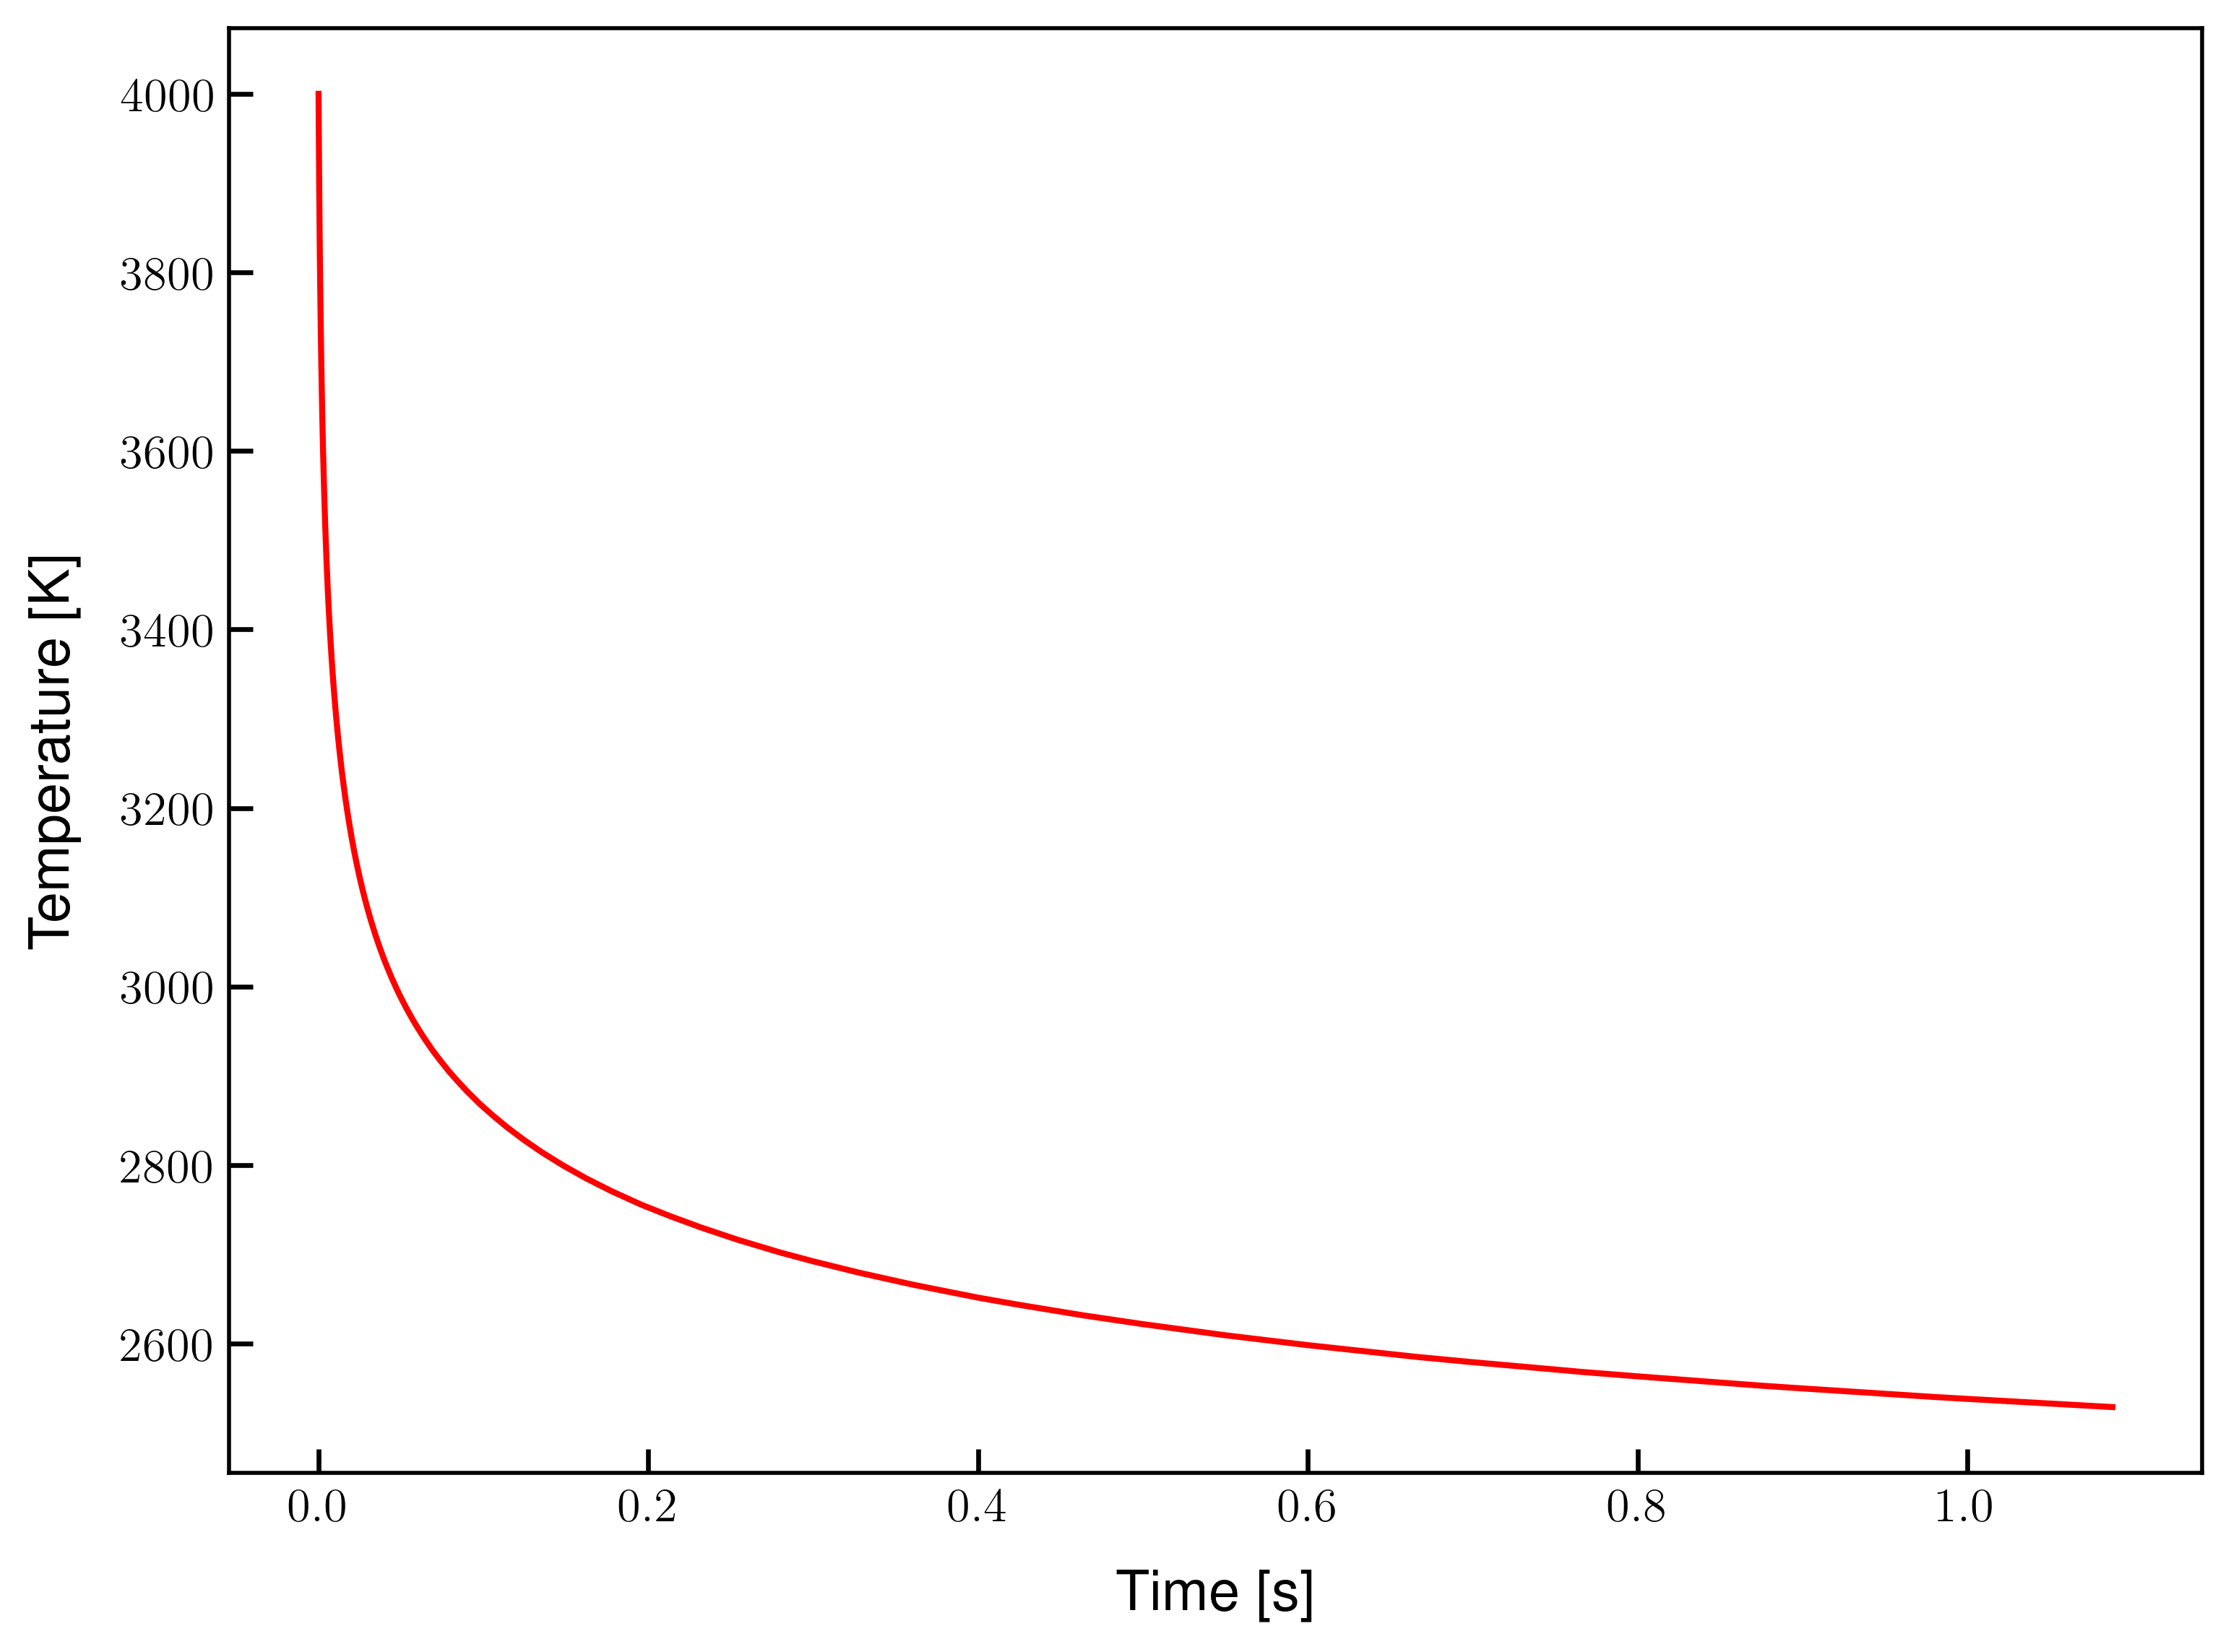

In [8]:
plt.figure()
plt.plot(time_reaction,temperature)
plt.ylabel('Temperature [K]')
plt.xlabel('Time [s]')

Text(0.5, 0, 'Time [s]')

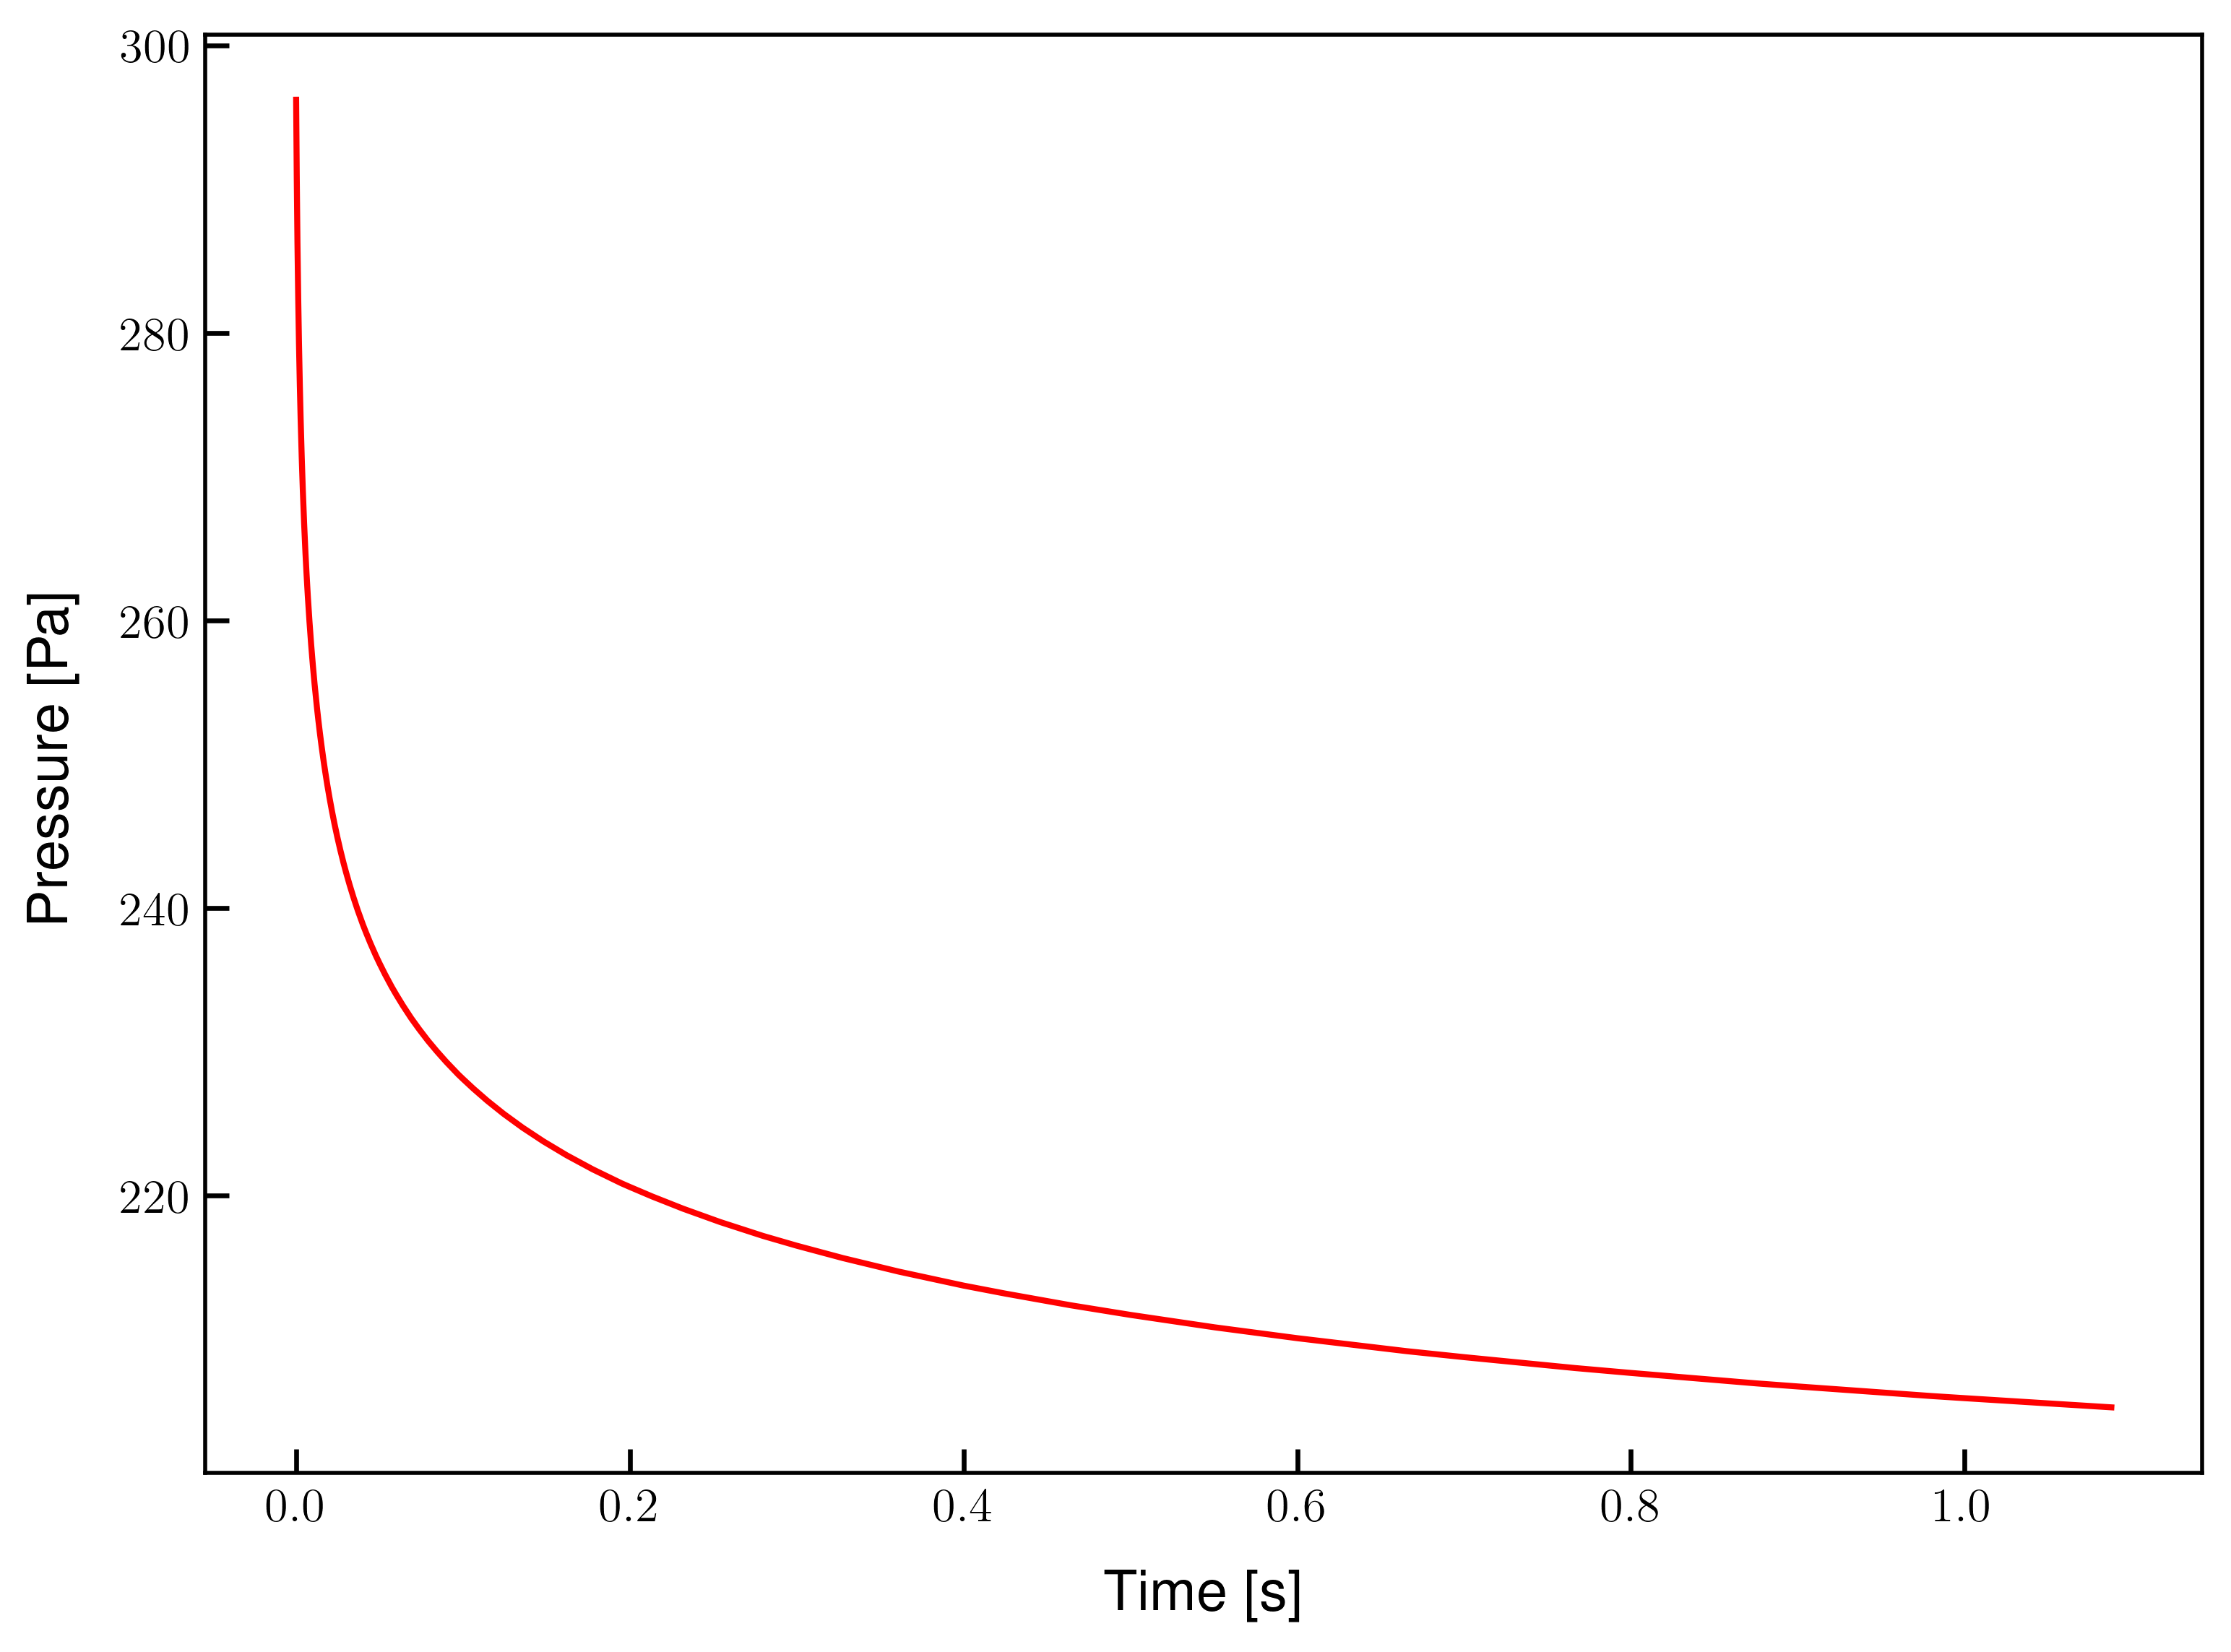

In [9]:
plt.figure()
plt.plot(time_reaction,pressure)
plt.ylabel('Pressure [Pa]')
plt.xlabel('Time [s]')

Text(0.5, 0, 'Time [s]')

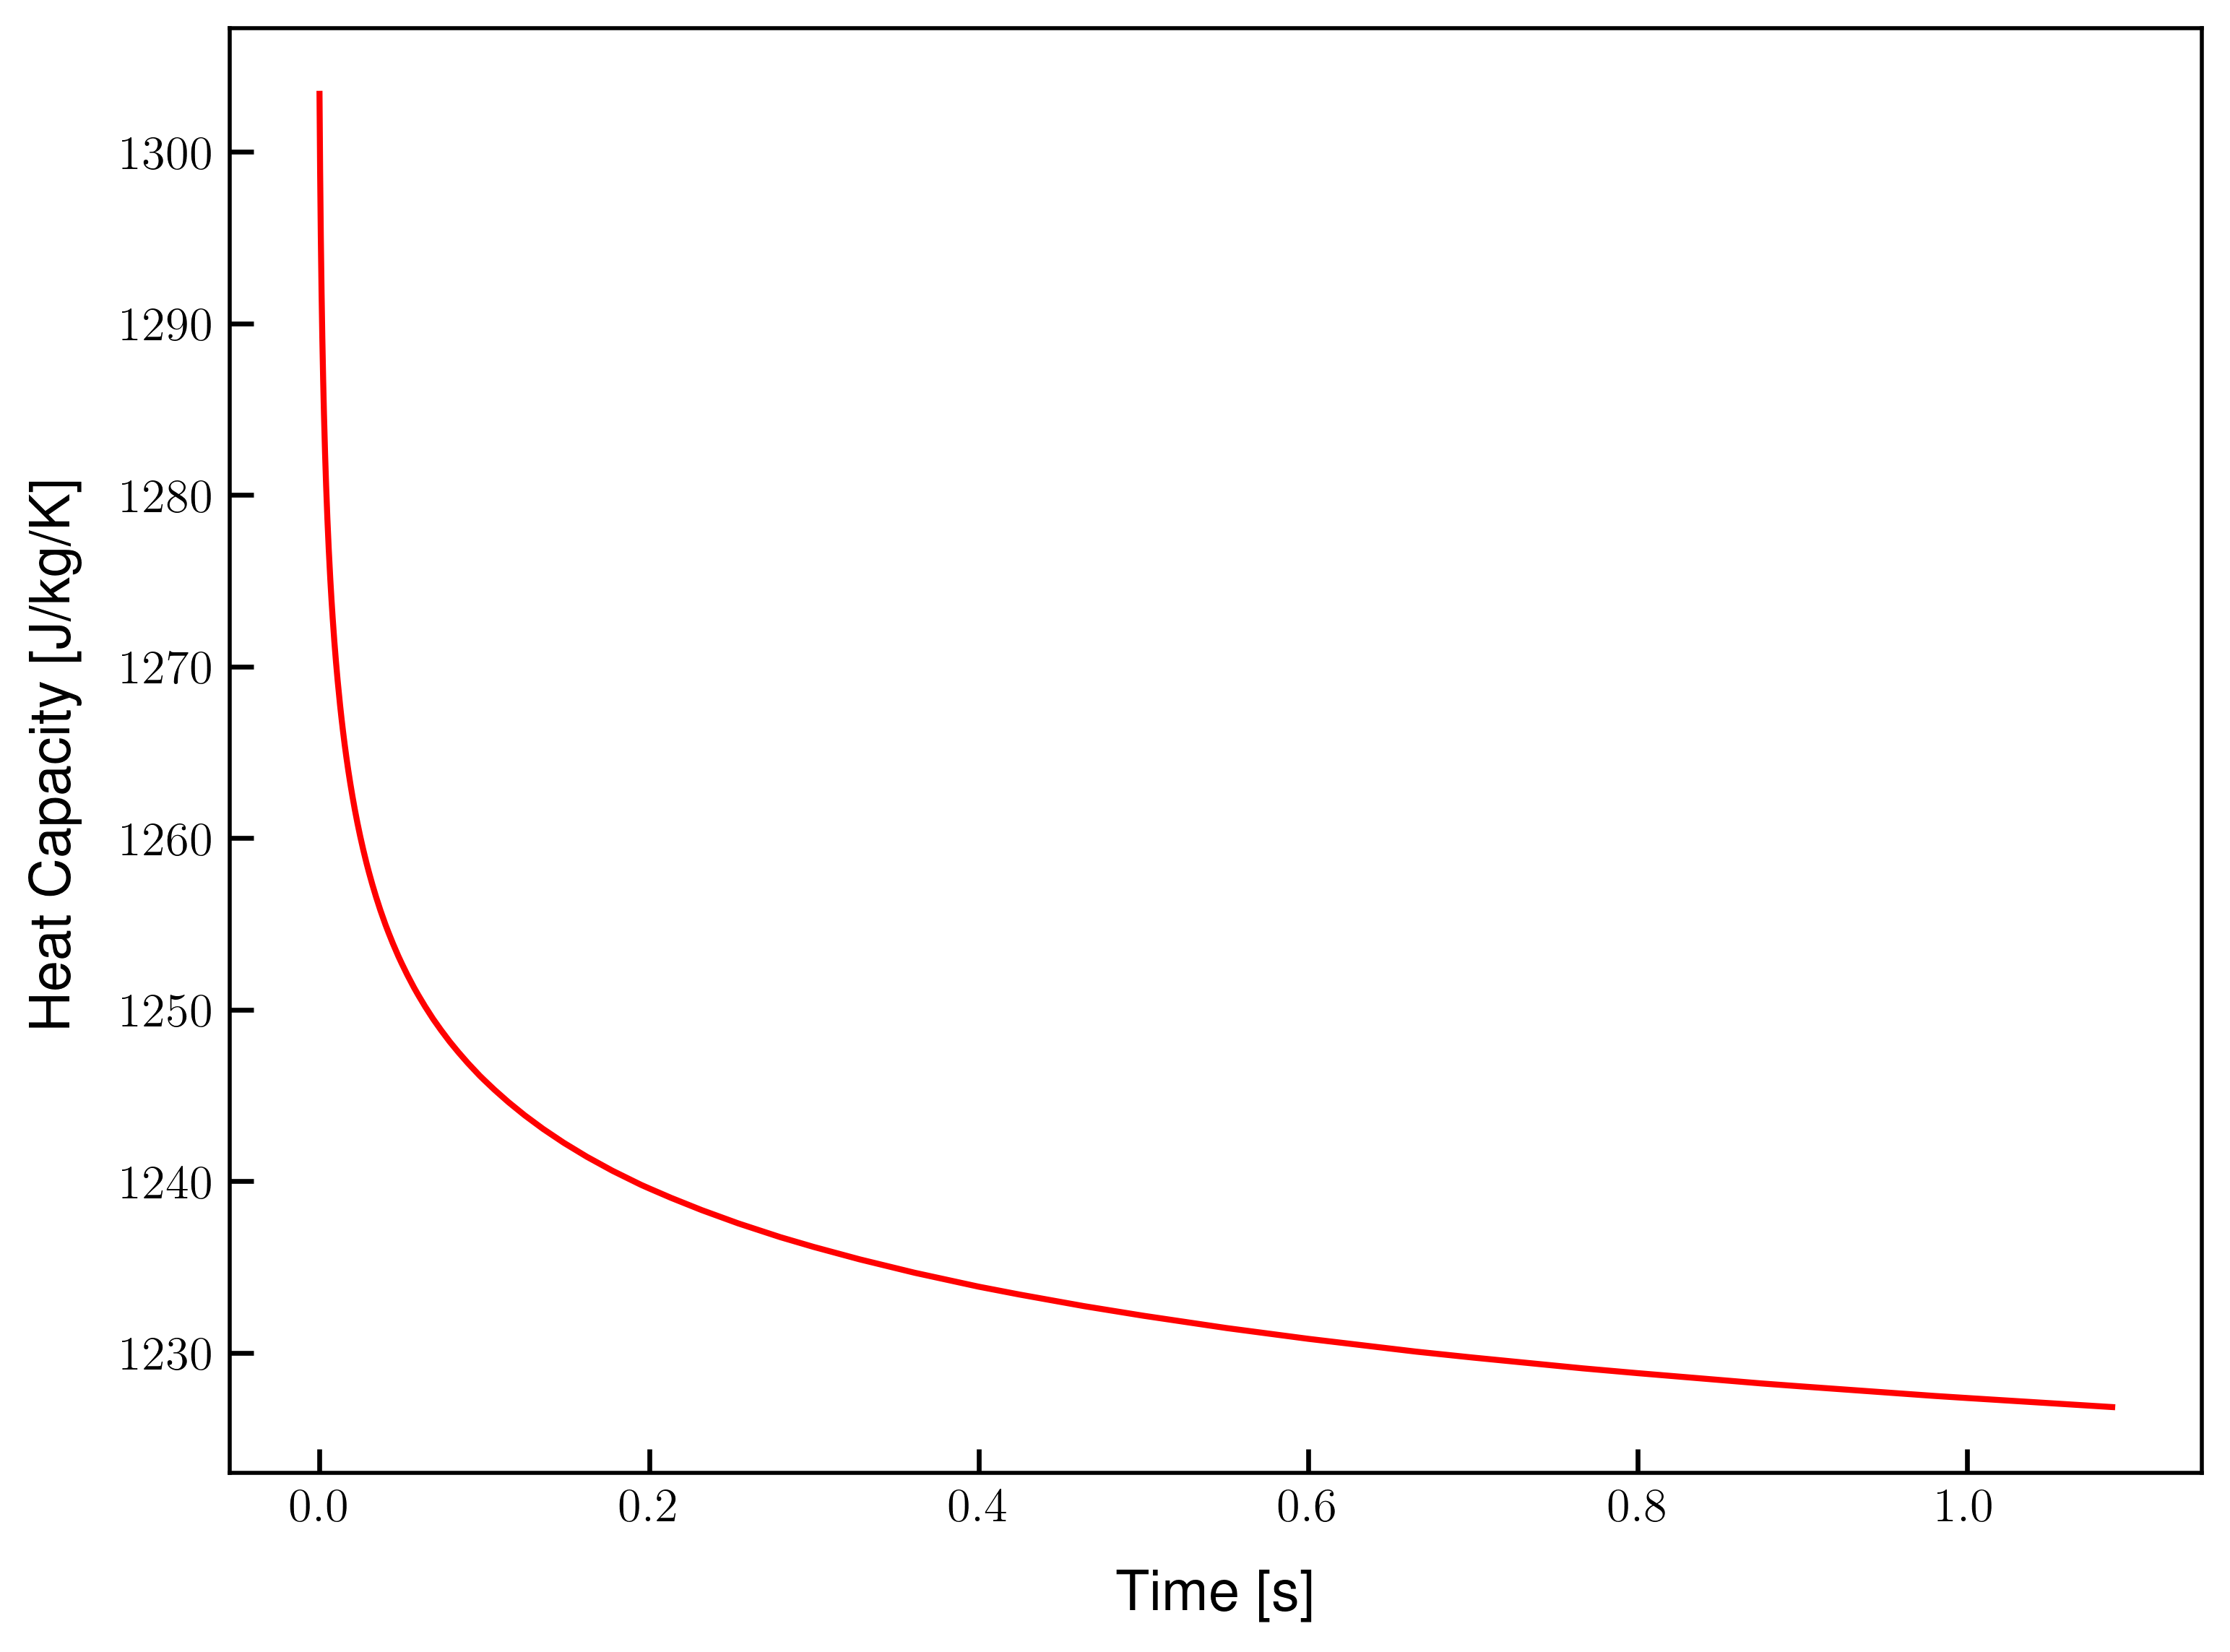

In [10]:
plt.figure()
plt.plot(time_reaction,Cps)
plt.ylabel('Heat Capacity [J/kg/K]')
plt.xlabel('Time [s]')